# N-1 Teacher action space — picking `k`

Exploratory analysis of the N-1 Teacher experience collected on **IEEE-36** (`l2rpn_wcci_2020`)
and **IEEE-118** (`l2rpn_wcci_2022`), to decide the `--top-k` handed to

```
python experiments/build_action_space.py aggregate --grid <grid> --top-k <k> --out <json>
```

**Run this in the `curriculum` conda env** (it needs `grid2op`, `lightsim2grid` and
`curriculumagent`):

```bash
module load devel/miniforge && eval "$(conda shell.bash hook)" && conda activate curriculum
jupyter lab experiments/teacher_action_space_analysis.ipynb
```

**Input:** `results/teacher/aggregated/experience_<grid>.csv` and `task_states_<grid>.csv`, both
written by `results/teacher/aggregate_shards.py`. Re-run that script to refresh as more SLURM
shards land.

**Data state (last run 2026-09-30).** The case118 array is finished (743 of 748 tasks completed,
5 killed at the walltime). The case36 array is ~85% through (699 of 864 tasks done, 40 running,
125 not started) and **159 of its tasks were killed at the 36 h walltime**, almost all in winter
months — §1b shows what that does to the data. case36 numbers will still move; §8 quantifies how
much.

**How each section is laid out.** Every experiment opens with a small table: whether it is
*necessary* for choosing `k`, its *goal*, *what is measured* and *how to read it*. The code cell
follows, then a one- or two-sentence **Conclusion** read off the output of this run.

In [1]:
from __future__ import annotations

import base64
import json
import sys
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_root(start: Path) -> Path:
    """Walk up from `start` until the repo root (the dir holding src/action_space_generation)."""
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "action_space_generation").is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {start}")


ROOT = find_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))

AGGREGATED = ROOT / "results" / "teacher" / "aggregated"

GRIDS = ["case36", "case118"]
ENV_NAMES = {"case36": "l2rpn_wcci_2020_train", "case118": "l2rpn_wcci_2022_train"}
ACTION_SPACE_DIRS = {
    "case36": ROOT / "data" / "action_spaces" / "l2rpn_wcci_2020",
    "case118": ROOT / "data" / "action_spaces" / "l2rpn_wcci_2022",
}
# From results/teacher/SUMMARY.md §2 — the contingencies the teacher searched against.
# case118 is the v2 list the array ran with (bridge line 72 replaced by 41, SUMMARY §4b).
LINES_TO_ATTACK = {
    "case36": [20, 13, 39, 33, 35, 32, 11, 34, 23, 22],
    "case118": [146, 136, 147, 135, 156, 149, 20, 154, 41, 12],
}
# SLURM array experiment dirs and chronics per array task (see aggregate_shards.py).
RUN_DIRS = {
    "case36": ROOT / "results" / "teacher" / "2026_09_17_teacher_n1_case36",
    "case118": ROOT / "results" / "teacher" / "2026_09_18_teacher_n1_case118",
}
CHUNK_SIZE = {"case36": 3, "case118": 2}

print(f"repo root: {ROOT}")

repo root: /pfs/data6/home/ka/ka_iai/ka_hw6998/dev/NRI-for-explainable-RL-in-Power-Grids


In [2]:
# ── Plot style: recessive axes, ink-coloured text, two validated categorical hues ──────────
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8983", "#e8e7e3"
SERIES = {"case36": "#2a78d6", "case118": "#eb6834"}  # categorical slots 1 and 2
SEQUENTIAL = "#2a78d6"  # single-hue ramp base for magnitude bars

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2.0,
    "font.size": 9,
})


def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Apply the shared chart furniture: left-aligned title, recessive grid behind the marks."""
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis=grid_axis)
    ax.set_axisbelow(True)
    return ax

## 1. Load the aggregated experience

**Terms used throughout.**

- **Row** — one line of a teacher output CSV, i.e. *one teacher decision that was saved*. The
  teacher steps through a chronic (one scenario time series, e.g. a month at 5-min resolution);
  a row is written only when the grid is in the N-1 band (`0.95 <= max rho < 1.0`) with every line
  in service **and** the N-1 search found a single-substation topology action that (1) pulls max
  rho below 0.95 and (2) keeps the grid alive under each of the 10 `lines_to_attack` outages
  (SUMMARY §4, §5). The row stores the chosen action and max rho before/after it. The same action
  can appear in many rows; *how many rows pick an action* is exactly what the export ranks on.
- **Shard** — the CSV written by one SLURM array task (`shard_<task>.csv`). Each task runs a fixed
  block of consecutive chronics: 3 for case36 (864 tasks x 3 = 2592 chronics), 2 for case118
  (748 x 2 = 1496). A task that never saved a row writes no CSV, so *shards <= tasks*. Rows carry
  no chronic id, so the shard is the finest provenance available.
- **Good row** — a row that `filter_good_experience` keeps (`rho_improvement > 0.02`); only good
  rows enter the ranking.

Columns (from `curriculumagent.teacher.submodule.common.save_sample_new`, plus provenance):

| column | meaning |
|---|---|
| `rho_max_old` | worst line loading **before** the action (`obs.rho.max()`) |
| `rho_max_new` | worst line loading **after** it |
| `rho_improvement` | the search's ranking score for the winner, `old_max_rho - new_max_rho` (**absolute**, not a percentage) |
| `best_action` | the chosen action, `base64(zlib(action._set_topo_vect))` |
| `top_0_action`, `top_0_ri` | the top-`k` candidate list; these runs used `top_k=1`, so `top_0_action == best_action` on every row |
| `grid`, `shard`, `chronic_first`, `chronic_last` | provenance added by `aggregate_shards.py` |
| `good` | would `filter_good_experience` keep this row (`rho_improvement > 0.02`) |

The table below counts array tasks by SLURM state, then shards, rows and unique actions.

In [3]:
raw = {grid: pd.read_csv(AGGREGATED / f"experience_{grid}.csv") for grid in GRIDS}
states = {grid: pd.read_csv(AGGREGATED / f"task_states_{grid}.csv") for grid in GRIDS}
n_tasks = {grid: -(-len((RUN_DIRS[grid] / "chronic_ids.txt").read_text().split()) // CHUNK_SIZE[grid])
           for grid in GRIDS}

overview = pd.DataFrame([
    {
        "grid": grid,
        "array tasks (total)": n_tasks[grid],
        "  completed": int((states[grid]["state"] == "COMPLETED").sum()),
        "  killed at walltime": int((states[grid]["state"] == "TIMEOUT").sum()),
        "  running": int((states[grid]["state"] == "RUNNING").sum()),
        "  not started": n_tasks[grid] - len(states[grid]),
        "shards (tasks with >= 1 row)": data["shard"].nunique(),
        "rows": len(data),
        "good rows (rho_improvement > 0.02)": int(data["good"].sum()),
        "unique actions (all rows)": data["best_action"].nunique(),
        "unique actions (good rows)": data.loc[data["good"], "best_action"].nunique(),
    }
    for grid, data in raw.items()
]).set_index("grid")
overview.T

grid,case36,case118
array tasks (total),864,748
completed,540,743
killed at walltime,159,5
running,40,0
not started,125,0
shards (tasks with >= 1 row),708,617
rows,13251,3533
good rows (rho_improvement > 0.02),10835,2829
unique actions (all rows),4407,2023
unique actions (good rows),3989,1724


**Conclusion.** case118 is effectively complete (743/748 tasks, 2,829 good rows over 1,724 actions); case36 already has ~4x the rows (10,835 good, 3,989 actions) but 125 tasks have not started and 159 were killed at the walltime.

### 1a. Sanity checks on the columns

| | |
|---|---|
| **Necessary?** | Yes — cheap, and every later cell silently relies on these properties. |
| **Goal** | Confirm the CSV columns mean what the rest of the notebook assumes. |
| **What is measured** | (i) `rho_max_old - rho_max_new - rho_improvement` residual; (ii) rows where `top_0_action != best_action`; (iii) do-nothing rows; (iv) range of `rho_max_old`; (v) exact duplicate rows within a shard. |
| **How to read it** | (i) should be float noise (~1e-7); (ii) and (iii) should be 0; (iv) must sit inside the N-1 band [0.95, 1.0); (v) a few duplicates are expected when the same state recurs in a chronic — many would mean rows are being written twice. |

In [4]:
# Sanity checks on the column semantics, so later cells can rely on them.
for grid, data in raw.items():
    residual = (data["rho_max_old"] - data["rho_max_new"] - data["rho_improvement"]).abs().max()
    print(f"{grid}:")
    print(f"  max |rho_max_old - rho_max_new - rho_improvement| = {residual:.2e}"
          "  (so rho_improvement is just the difference of the two rho columns)")
    print(f"  rows where top_0_action != best_action: {(data['best_action'] != data['top_0_action']).sum()}")
    print(f"  encoded do-nothing rows (best_action == '0'): {(data['best_action'] == '0').sum()}")
    print(f"  rho_max_old range: {data['rho_max_old'].min():.3f} .. {data['rho_max_old'].max():.3f}"
          f"  (mean {data['rho_max_old'].mean():.3f})")
    print(f"  exact duplicate rows: {data.duplicated(subset=['rho_max_old', 'rho_max_new', 'best_action', 'shard']).sum()}")

case36:
  max |rho_max_old - rho_max_new - rho_improvement| = 9.00e-08  (so rho_improvement is just the difference of the two rho columns)
  rows where top_0_action != best_action: 0
  encoded do-nothing rows (best_action == '0'): 0
  rho_max_old range: 0.950 .. 1.000  (mean 0.968)
  exact duplicate rows: 0
case118:
  max |rho_max_old - rho_max_new - rho_improvement| = 1.00e-07  (so rho_improvement is just the difference of the two rho columns)
  rows where top_0_action != best_action: 0
  encoded do-nothing rows (best_action == '0'): 0
  rho_max_old range: 0.950 .. 1.000  (mean 0.967)
  exact duplicate rows: 42


**Conclusion.** Every assumption holds on both grids (residual <= 1e-7, `top_0_action == best_action`, no do-nothing rows, `rho_max_old` inside [0.95, 1.0)). The 42 exact duplicates on case118 are ~1% of its rows, too few to move the ranking.

### 1b. Coverage: which months made it into the data

| | |
|---|---|
| **Necessary?** | Yes — new in this run. 159 case36 tasks were killed at the 36 h walltime, and a killed task loses the tail of its last chronic. If the kills cluster by season, the ranking is biased towards the months that finished. |
| **Goal** | Decide whether the truncated chronics need a rerun (at 72 h) before the ranking is trusted. |
| **What is measured** | Per calendar month: array tasks by SLURM state, total rows, mean rows per finished task, and the share of finished tasks that were killed. |
| **How to read it** | A high `timeout share` means that month is under-sampled relative to how often the teacher would have acted there. High `rows per finished task` marks a month where the grid is often stressed — exactly the months a timeout hurts most. |

In [5]:
MONTHS = ["january", "february", "march", "april", "may", "june", "july", "august",
          "september", "october", "november", "december"]


def chronic_month(grid: str, chronic_path: str) -> str:
    """Calendar month of a chronic, from its directory name."""
    name = Path(chronic_path).name
    if grid == "case36":  # Scenario_<month>_<nnn>
        return name.split("_")[1]
    return MONTHS[int(name.split("-")[1]) - 1]  # case118: 2050-<mm>-<dd>_<n>


def coverage_by_month(grid: str) -> pd.DataFrame:
    """Per calendar month: how many tasks finished, were killed, or are still to run, and the rows."""
    chronics = (RUN_DIRS[grid] / "chronic_ids.txt").read_text().split()
    task_month = pd.Series({task: chronic_month(grid, chronics[task * CHUNK_SIZE[grid]])
                            for task in range(n_tasks[grid])}, name="month")
    task_state = states[grid].set_index("task")["state"].reindex(task_month.index).fillna("NOT STARTED")
    rows_per_task = raw[grid].groupby("shard").size().reindex(task_month.index, fill_value=0)
    frame = pd.DataFrame({"month": task_month, "state": task_state, "rows": rows_per_task})
    table = pd.crosstab(frame["month"], frame["state"])
    table["rows"] = frame.groupby("month")["rows"].sum()
    finished = frame[frame["state"].isin(["COMPLETED", "TIMEOUT"])]
    table["rows per finished task"] = finished.groupby("month")["rows"].mean().round(1)
    table["timeout share"] = (table.get("TIMEOUT", 0) /
                              table[[c for c in ("COMPLETED", "TIMEOUT") if c in table]].sum(axis=1)
                              ).map("{:.0%}".format)
    return table.reindex([m for m in MONTHS if m in table.index])


coverage = {grid: coverage_by_month(grid) for grid in GRIDS}
for grid, table in coverage.items():
    print(f"{grid}:")
    print(table.to_string(), "\n")

case36:
state      COMPLETED  NOT STARTED  RUNNING  TIMEOUT  rows  rows per finished task timeout share
month                                                                                          
january           37            0        0       35  2250                    31.2           49%
february          34            0        0       38  2198                    30.5           53%
march             34            0        0       37  2099                    29.6           52%
april             72            0        0        0   812                    11.3            0%
may               71            0        0        1   679                     9.4            1%
june              73            0        0        0   526                     7.2            0%
july              70            0        0        0   107                     1.5            0%
august            72            0        0        0   286                     4.0            0%
september          0           7

**Conclusion.** **case36 is biased against its highest-yield months:** November-March produce 28-32 rows per task (3-4x april-june), and 29-54% of those tasks were killed at the walltime, while September/October have not run yet. case118 is unaffected (<= 3% timeouts in any month), so the truncated case36 winter chronics should be rerun at 72 h before its ranking is final.

## 2. What the `rho_improvement > 0.02` filter does

| | |
|---|---|
| **Necessary?** | Not for choosing `k` — the 0.02 cut is hard-coded upstream and applied by the export regardless. Kept because it is cheap and would reveal if the cut were quietly removing most of the data. |
| **Goal** | Show how much data and how many distinct actions the fixed filter removes. |
| **What is measured** | Histogram of `rho_improvement` per row; rows and unique actions surviving thresholds 0-0.2. |
| **How to read it** | If the 0.02 row loses only a small fraction versus 0.0, the filter is not what shapes the action set and can be taken as given. |

,case36 rows,case118 rows,case36 actions,case118 actions
threshold,,,,
0.00,11999,3383,4181,1959
0.01,11419,3174,4088,1874
0.02,10835,2829,3989,1724
0.05,9266,1956,3603,1318
0.10,6858,1092,2847,847
0.20,2802,324,1243,284


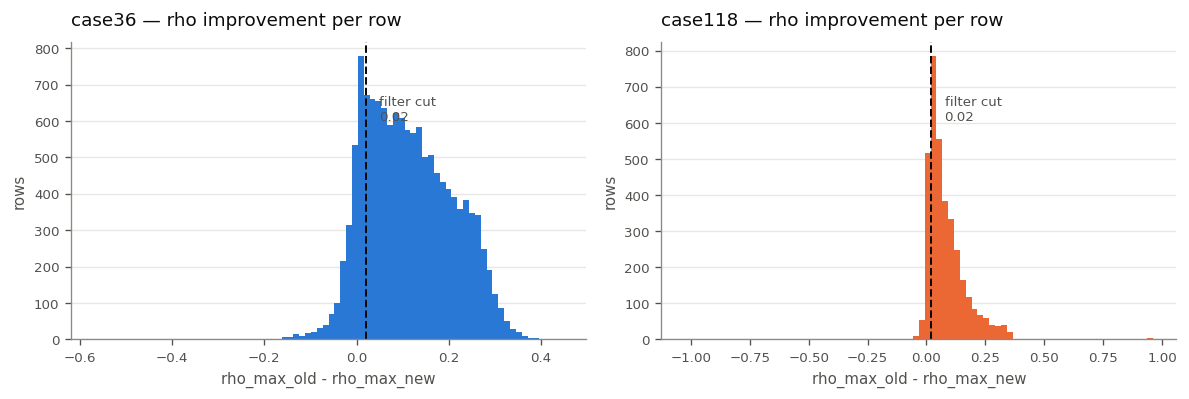

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

for ax, (grid, data) in zip(axes, raw.items()):
    ax.hist(data["rho_improvement"], bins=80, color=SERIES[grid], edgecolor="none")
    ax.axvline(0.02, color=INK, lw=1.2, ls="--")
    ax.annotate("filter cut\n0.02", xy=(0.02, ax.get_ylim()[1] * 0.82),
                xytext=(8, 0), textcoords="offset points", color=INK2, fontsize=8, va="top")
    style(ax, title=f"{grid} — rho improvement per row",
          xlabel="rho_max_old - rho_max_new", ylabel="rows")
fig.tight_layout()

sweep = pd.DataFrame([
    {
        "threshold": t,
        **{f"{grid} rows": int((data["rho_improvement"] > t).sum()) for grid, data in raw.items()},
        **{f"{grid} actions": int(data.loc[data["rho_improvement"] > t, "best_action"].nunique())
           for grid, data in raw.items()},
    }
    for t in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2]
]).set_index("threshold")
sweep

**Conclusion.** The 0.02 cut drops 10% of rows and 5% of actions on case36 (16% / 12% on case118) relative to no cut, so it trims marginal rows but does not shape the action set.

## 3. The knee: rank vs. times picked

| | |
|---|---|
| **Necessary?** | Yes — this curve *is* the selection rule: `rank_actions_simple` keeps the first `k` entries of `best_action.value_counts()`. |
| **Goal** | Find a `k` where adding more actions stops buying much coverage. |
| **What is measured** | Left: picks per action, sorted (log-log), with a Kneedle-style knee (the rank furthest from the chord between the curve's endpoints after normalising log-frequency). Right: cumulative share of good picks covered by the top-`k`. |
| **How to read it** | A sharp knee and a coverage curve that saturates early mean a small `k` suffices. A flat curve (few picks per action even at the head) means the ranking beyond the first handful is weakly supported and `k` should be chosen by coverage, not by knee. The knee is a hint, not an answer. |

grid,case36,case118
unique actions,3989,1724
top pick count,264,15
knee (heuristic),782,516
freq@25,38,7
freq@50,23,5
freq@100,13,4
freq@200,8,3
freq@400,4,2
cover@100,33%,22%
cover@200,43%,34%


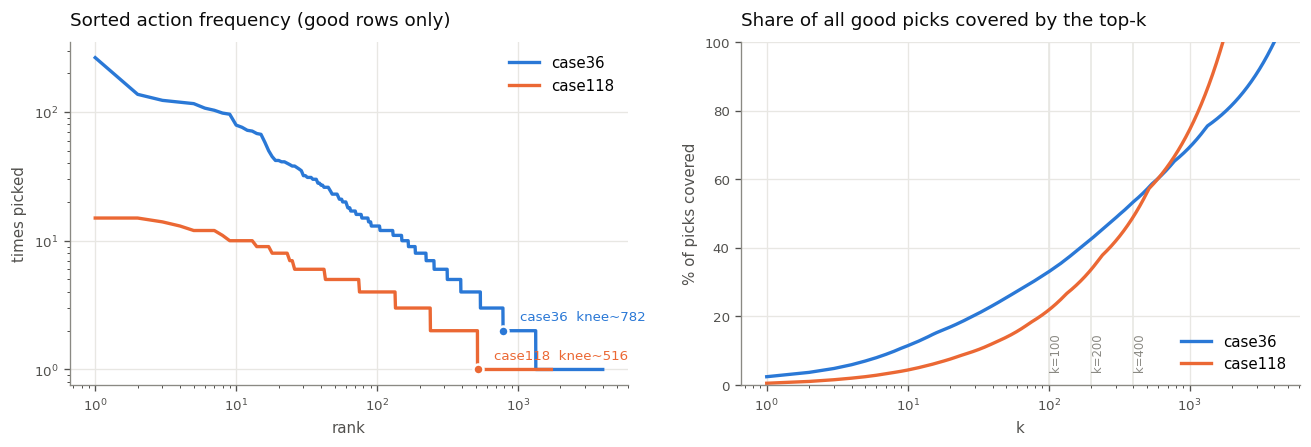

In [7]:
def frequency_curve(data: pd.DataFrame, good_only: bool = True) -> pd.Series:
    """Times each encoded action was picked, most-picked first — the tool's own ranking."""
    rows = data[data["good"]] if good_only else data
    return rows["best_action"].value_counts()


def knee_rank(frequencies) -> int:
    """Kneedle-style elbow of a decreasing curve: the rank furthest from the endpoint chord."""
    y = np.log10(np.asarray(frequencies, dtype=float))
    x = np.arange(1, len(y) + 1, dtype=float)
    if len(y) < 3 or y.max() == y.min():
        return len(y)
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    return int(np.argmax(np.abs(y_norm - (1.0 - x_norm))) + 1)


curves = {grid: frequency_curve(data) for grid, data in raw.items()}
knees = {grid: knee_rank(curve.values) for grid, curve in curves.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
for grid, curve in curves.items():
    ranks = np.arange(1, len(curve) + 1)
    ax.plot(ranks, curve.values, color=SERIES[grid], label=grid)
    ax.scatter([knees[grid]], [curve.values[knees[grid] - 1]], s=36, zorder=3,
               color=SERIES[grid], edgecolor="white", linewidth=1.5)
    ax.annotate(f"{grid}  knee~{knees[grid]}", xy=(knees[grid], curve.values[knees[grid] - 1]),
                xytext=(10, 6), textcoords="offset points", color=SERIES[grid], fontsize=8)
ax.set_yscale("log")
ax.set_xscale("log")
style(ax, title="Sorted action frequency (good rows only)",
      xlabel="rank", ylabel="times picked", grid_axis="both")
ax.legend(loc="upper right")

ax = axes[1]
for grid, curve in curves.items():
    share = np.cumsum(curve.values) / curve.values.sum() * 100
    ax.plot(np.arange(1, len(curve) + 1), share, color=SERIES[grid], label=grid)
for k in (100, 200, 400):
    ax.axvline(k, color=GRID, lw=1.0, zorder=0)
    ax.annotate(f"k={k}", xy=(k, 4), color=MUTED, fontsize=7, rotation=90, va="bottom")
ax.set_xscale("log")
ax.set_ylim(0, 100)
style(ax, title="Share of all good picks covered by the top-k",
      xlabel="k", ylabel="% of picks covered", grid_axis="both")
ax.legend(loc="lower right")
fig.tight_layout()

pd.DataFrame([
    {
        "grid": grid,
        "unique actions": len(curve),
        "top pick count": int(curve.iloc[0]),
        "knee (heuristic)": knees[grid],
        **{f"freq@{k}": (int(curve.iloc[k - 1]) if len(curve) >= k else None)
           for k in (25, 50, 100, 200, 400)},
        **{f"cover@{k}": (f"{curve.iloc[:k].sum() / curve.sum() * 100:.0f}%" if len(curve) >= k else None)
           for k in (100, 200, 400)},
    }
    for grid, curve in curves.items()
]).set_index("grid").T

**Conclusion.** Neither grid has a usable knee: the heuristic lands at rank 782 / 516, and coverage rises slowly (top-200 covers 43% of case36 picks, 34% of case118's). case118's curve is nearly flat (the top action has 15 picks, rank 100 has 4), so `k` has to be chosen by coverage and stability (§8), not by the knee.

## 4. Decode the actions

| | |
|---|---|
| **Necessary?** | Yes — infrastructure. Every section from §5 on needs the substation each action touches. |
| **Goal** | Turn each base64 string back into its topology vector and substation, and check that this notebook's ranking is exactly the one the export uses. |
| **What is measured** | `action_table` per grid (rank, picks, shard support, substation, bus split, rho statistics); then a cross-check against the repo's `load_experience` / `action_frequency` / `substation_distribution`. |
| **How to read it** | Both cross-checks must print `True`; otherwise the notebook analyses a different ranking than the one `build_action_space.py aggregate` would export. |

`EncodedTopologyAction.encode_action` is `base64(zlib(action._set_topo_vect, level=1))`, so the
string is a deterministic function of the topology vector and can be decoded back without an
environment. The environment is still needed for `sub_info`, which maps a position in the topology
vector to its substation. Loading two Grid2Op environments takes a while; they are cached and reused.

In [8]:
import grid2op
from lightsim2grid import LightSimBackend

_ENV_CACHE: dict[str, object] = {}


def get_env(grid: str):
    """Return a cached Grid2Op environment for `grid`."""
    if grid not in _ENV_CACHE:
        _ENV_CACHE[grid] = grid2op.make(ENV_NAMES[grid], backend=LightSimBackend())
    return _ENV_CACHE[grid]


def decode_topo_vect(encoded: str) -> np.ndarray:
    """Undo `EncodedTopologyAction.encode_action` — 0 = untouched, 1/2 = busbar, -1 = disconnect."""
    return np.frombuffer(zlib.decompress(base64.b64decode(encoded.encode("utf-8"))), dtype=np.int32)


def position_to_substation(grid: str) -> np.ndarray:
    """Lookup array mapping each topology-vector position to its substation id."""
    sub_info = get_env(grid).action_space.sub_info
    return np.repeat(np.arange(len(sub_info)), sub_info)


def action_table(grid: str) -> pd.DataFrame:
    """One row per unique action in the good experience, with its rank and decoded structure.

    `picks` is the frequency the export ranks on; `shard_support` counts how many distinct SLURM
    shards (i.e. groups of chronics) the action was picked in, which separates an action that is
    broadly useful from one that a single scenario picked repeatedly.
    """
    good = raw[grid][raw[grid]["good"]]
    pos2sub = position_to_substation(grid)

    picks = good["best_action"].value_counts()
    support = good.groupby("best_action")["shard"].nunique()
    improvement = good.groupby("best_action")["rho_improvement"].agg(["mean", "median", "max", "sum"])

    records = []
    for rank, (encoded, n_picks) in enumerate(picks.items(), start=1):
        topo_vect = decode_topo_vect(encoded)
        substations = np.unique(pos2sub[topo_vect > 0])
        configuration = topo_vect[pos2sub == substations[0]]
        records.append({
            "rank": rank,
            "encoded": encoded,
            "picks": int(n_picks),
            "shard_support": int(support[encoded]),
            "sub": int(substations[0]),
            "n_substations": len(substations),
            "n_objects": len(configuration),
            "n_on_bus2": int((configuration == 2).sum()),
            "n_unset": int((configuration == 0).sum()),
            "ri_mean": improvement.loc[encoded, "mean"],
            "ri_median": improvement.loc[encoded, "median"],
            "ri_max": improvement.loc[encoded, "max"],
            "ri_sum": improvement.loc[encoded, "sum"],
        })
    return pd.DataFrame(records)


tables = {grid: action_table(grid) for grid in GRIDS}
for grid, table in tables.items():
    print(f"{grid}: {len(table)} unique good actions")
tables["case36"].head(10)

/home/ka/ka_iai/ka_hw6998/.conda/envs/curriculum/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


case36: 3989 unique good actions
case118: 1724 unique good actions


,rank,encoded,picks,shard_support,sub,n_substations,n_objects,n_on_bus2,n_unset,ri_mean,ri_median,ri_max,ri_sum
0,1,eAFjYEAARiATG0aoGGWNhsDgCwEAEtgABw==,264,189,1,1,6,0,0,0.122475,0.122719,0.285896,32.333351
1,2,eAFjYBj6gBHoBWQ89H006gNSQgAACqwABQ==,137,120,12,1,4,0,0,0.096063,0.086083,0.299156,13.160660
2,3,eAFjYBiagBHobCYgBtGjYGSHAAAK5AAF,123,104,11,1,3,1,0,0.200964,0.215963,0.348048,24.718574
3,4,eAFjYCAfMAK1omMm8o0b1TkaAmSFAAAULAAI,119,93,4,1,6,1,0,0.217434,0.229122,0.380456,25.874635
4,5,eAFjYBiagBHobBgemj4YdTW1QgAACNwABA==,116,99,11,1,3,0,0,0.096575,0.082125,0.285525,11.202722
5,6,eAFjYBgFtA4BRqAFMExru0ai+QAG2AAE,107,85,19,1,3,0,0,0.140921,0.132855,0.272856,15.078525
6,7,eAFjYCAfMAK1wjATlA2iR8FoCNAzBAAWqAAJ,103,88,4,1,6,2,0,0.211600,0.226797,0.353849,21.794832
7,8,eAFjYBgFjMAgAGEmKA1jg/joGJccUOkoGKAQAAAxkAAe,98,83,16,1,17,12,0,0.227237,0.235067,0.339550,22.269198
8,9,eAFjYBgFoyEw+EOAEehEXBgAAzQACA==,96,86,35,1,7,0,0,0.128487,0.121040,0.309180,12.334730
9,10,eAFjYBgF1AgBRqAhMEwN80bNID4EAAcsAAQ=,79,69,17,1,3,0,0,0.103795,0.083924,0.336055,8.199772


In [9]:
# Cross-check the fast vector path against the repo's own helpers on the real pipeline entry point.
from action_space_generation.aggregation import (
    action_frequency,
    load_experience,
    select_top_k_actions,
    substation_distribution,
)

for grid in GRIDS:
    reference = load_experience([AGGREGATED / f"experience_{grid}.csv"])
    reference_frequency = action_frequency(reference)
    mine = tables[grid].set_index("encoded")["picks"]
    aligned = reference_frequency.reindex(mine.index)
    print(f"{grid}: load_experience rows={len(reference)}  unique={len(reference_frequency)}"
          f"  frequencies identical to this notebook's: {bool((aligned == mine).all())}")

    # substation_distribution decodes through the env; agrees with the pos2sub mapping used above.
    top_actions = select_top_k_actions(reference, get_env(grid), k=50)
    from_repo = substation_distribution(top_actions).sort_index()
    from_notebook = tables[grid].head(50)["sub"].value_counts().sort_index()
    print(f"  substation_distribution on the top 50 matches: "
          f"{bool(from_repo.equals(from_notebook.astype(from_repo.dtype)))}")

case36: load_experience rows=10835  unique=3989  frequencies identical to this notebook's: True
  substation_distribution on the top 50 matches: True
case118: load_experience rows=2829  unique=1724  frequencies identical to this notebook's: True
  substation_distribution on the top 50 matches: True


**Conclusion.** Both cross-checks print `True`: the notebook ranks exactly what `build_action_space.py aggregate` would export.

## 5. Action frequency per substation

| | |
|---|---|
| **Necessary?** | Yes, as the explanation for §6: it shows *where* the concentration comes from. |
| **Goal** | See where the teacher's fixes land, separating 'this substation is big' from 'this substation is useful'. |
| **What is measured** | Picks per substation (raw), and picks divided by the substation's object count; top-1 / top-5 share of picks; effective number of substations `1/HHI` (HHI = sum of squared pick shares). |
| **How to read it** | `1/HHI` near 1-3 means the teacher leans on a couple of substations; a value close to the number of substations reached means picks are spread evenly. A substation high on the right panel but not the left is small but disproportionately useful. |

grid,case36,case118
substations reached,33,72
of total,36,118
top-1 share of picks,49.5%,24.4%
top-5 share of picks,73.0%,58.7%
effective substations (1/HHI),3.7,9.7


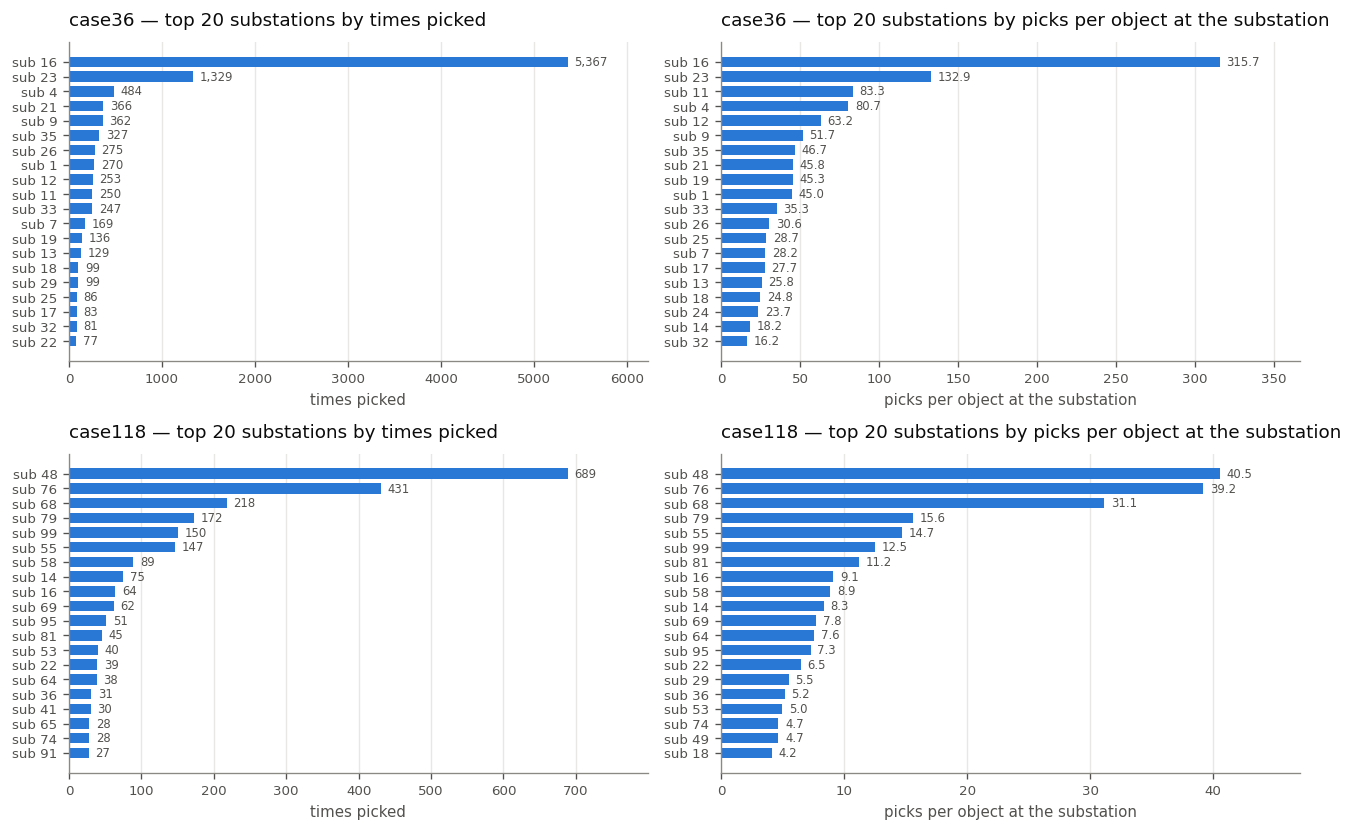

In [10]:
def substation_picks(grid: str) -> pd.DataFrame:
    """Per-substation pick counts, unique-action counts and size, sorted by picks."""
    table, sub_info = tables[grid], get_env(grid).action_space.sub_info
    grouped = table.groupby("sub").agg(picks=("picks", "sum"), actions=("encoded", "size"))
    grouped["n_objects"] = sub_info[grouped.index]
    grouped["picks_per_object"] = grouped["picks"] / grouped["n_objects"]
    return grouped.sort_values("picks", ascending=False)


sub_stats = {grid: substation_picks(grid) for grid in GRIDS}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
TOP_N = 20

for row, grid in enumerate(GRIDS):
    stats = sub_stats[grid]
    for col, (column, label) in enumerate([("picks", "times picked"),
                                           ("picks_per_object", "picks per object at the substation")]):
        ax = axes[row][col]
        shown = stats.sort_values(column, ascending=False).head(TOP_N).iloc[::-1]
        positions = np.arange(len(shown))
        # Single series -> one sequential hue; magnitude is already carried by bar length.
        ax.barh(positions, shown[column].values, height=0.72, color=SEQUENTIAL, edgecolor="none")
        ax.set_yticks(positions)
        ax.set_yticklabels([f"sub {i}" for i in shown.index])
        for y, value in zip(positions, shown[column].values):
            ax.annotate(f"{value:,.0f}" if column == "picks" else f"{value:,.1f}",
                        xy=(value, y), xytext=(4, 0), textcoords="offset points",
                        va="center", fontsize=7, color=INK2)
        ax.margins(x=0.16)
        style(ax, title=f"{grid} — top {TOP_N} substations by {label}", xlabel=label, grid_axis="x")

fig.tight_layout()

pd.DataFrame([
    {
        "grid": grid,
        "substations reached": len(sub_stats[grid]),
        "of total": len(get_env(grid).action_space.sub_info),
        "top-1 share of picks": f"{sub_stats[grid]['picks'].iloc[0] / sub_stats[grid]['picks'].sum():.1%}",
        "top-5 share of picks": f"{sub_stats[grid]['picks'].head(5).sum() / sub_stats[grid]['picks'].sum():.1%}",
        # Herfindahl index: 1/HHI is the "effective number" of substations in play.
        "effective substations (1/HHI)":
            round(1 / ((sub_stats[grid]["picks"] / sub_stats[grid]["picks"].sum()) ** 2).sum(), 1),
    }
    for grid in GRIDS
]).set_index("grid").T

**Conclusion.** case36 leans on one substation: **sub 16 (17 objects) takes 49.5% of all picks** and the effective number of substations is only 3.7. case118 is much more even (top substation 48 at 24%, 1/HHI = 9.7).

## 6. Does the top-k spread across substations?

| | |
|---|---|
| **Necessary?** | Yes — the handoff's acceptance criterion: the exported set must not be concentrated on one or two substations. |
| **Goal** | Decide whether a plain frequency top-`k` is usable at all. |
| **What is measured** | Distinct substations among the top-`k` actions, and the share of the top-`k` that the single largest substation holds, for k = 50-400. |
| **How to read it** | The criterion is met if the top-`k` touches many substations and no single substation holds a large share of the *actions* (roughly > 1/3 would be a warning). |

substations largest substation share picks covered
grid    k                                                      
case36  50            19                    18.0%           25%
        100           23                    22.0%           33%
        200           25                    24.0%           43%
        400           26                    33.2%           53%
case118 50            19                    26.0%           14%
        100           28                    26.0%           22%
        200           38                    23.5%           34%
        400           45                    19.5%           49%

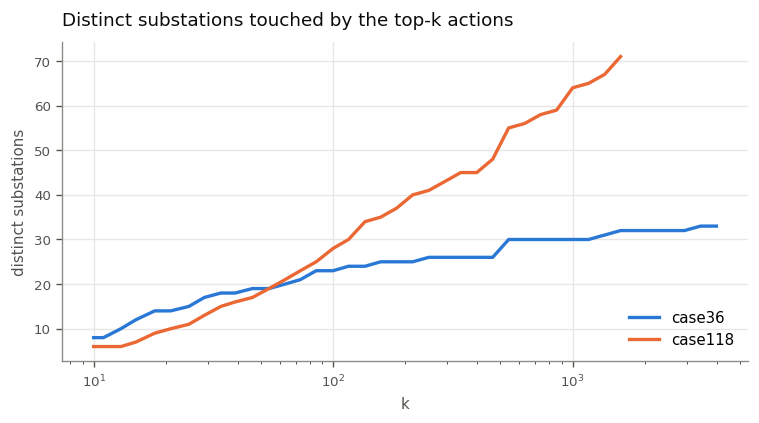

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ks = np.unique(np.geomspace(10, max(len(t) for t in tables.values()), 40).astype(int))

spread_rows = []
for grid, table in tables.items():
    xs = [k for k in ks if k <= len(table)]
    ys = [table.head(k)["sub"].nunique() for k in xs]
    ax.plot(xs, ys, color=SERIES[grid], label=grid)
    for k in (50, 100, 200, 400):
        if k <= len(table):
            head = table.head(k)
            spread_rows.append({
                "grid": grid, "k": k,
                "substations": head["sub"].nunique(),
                "largest substation share": f"{head['sub'].value_counts().iloc[0] / k:.1%}",
                "picks covered": f"{head['picks'].sum() / table['picks'].sum():.0%}",
            })
ax.set_xscale("log")
style(ax, title="Distinct substations touched by the top-k actions",
      xlabel="k", ylabel="distinct substations", grid_axis="both")
ax.legend(loc="lower right")
fig.tight_layout()

pd.DataFrame(spread_rows).set_index(["grid", "k"])

**Conclusion.** The criterion holds for both grids at the level of *actions*: the top-100 touches 23 (case36) / 28 (case118) substations, and no substation holds more than ~26% of them. case36 creeps to 33% at k = 400, so a large case36 `k` gets close to the warning level.

## 7. Is the ranking concentrated where we *made* it congested?

| | |
|---|---|
| **Necessary?** | Yes, for interpretation. The teacher only saves rows under the 10 `lines_to_attack` contingencies, so the ranking may reflect that choice more than the grid. |
| **Goal** | Measure how much of the action set sits at the ends of attacked lines. |
| **What is measured** | Each substation is labelled *on attacked line*, *one hop away* or *farther* (graph distance from an attacked line's endpoints); unique actions, picks and top-100 share per label. |
| **How to read it** | Compare with the base rate: 10 attacked lines have at most 20 endpoints, a small fraction of the substations. A share of picks far above that base rate means the action set is specialised to these contingencies and may generalise poorly to others. |

In [12]:
def attack_rings(grid: str) -> dict[int, str]:
    """Label each substation `on attacked line`, `one hop away` or `farther`."""
    action_space = get_env(grid).action_space
    or_sub, ex_sub = action_space.line_or_to_subid, action_space.line_ex_to_subid

    attacked = {int(s) for line in LINES_TO_ATTACK[grid] for s in (or_sub[line], ex_sub[line])}
    neighbours = set()
    for line in range(action_space.n_line):
        origin, extremity = int(or_sub[line]), int(ex_sub[line])
        if origin in attacked:
            neighbours.add(extremity)
        if extremity in attacked:
            neighbours.add(origin)
    neighbours -= attacked

    labels = {}
    for sub in range(len(action_space.sub_info)):
        labels[sub] = ("on attacked line" if sub in attacked
                       else "one hop away" if sub in neighbours else "farther")
    return labels


ring_rows = []
for grid, table in tables.items():
    labels = attack_rings(grid)
    ring = table.assign(ring=table["sub"].map(labels))
    by_ring = ring.groupby("ring").agg(actions=("encoded", "size"), picks=("picks", "sum"))
    for name, row in by_ring.iterrows():
        ring_rows.append({
            "grid": grid, "ring": name,
            "unique actions": int(row["actions"]),
            "picks": int(row["picks"]),
            "share of substations": f"{sum(v == name for v in labels.values()) / len(labels):.0%}",
            "share of picks": f"{row['picks'] / by_ring['picks'].sum():.1%}",
            "share of top-100": f"{(ring.head(100)['ring'] == name).mean():.0%}",
        })

pd.DataFrame(ring_rows).set_index(["grid", "ring"])

unique actions  picks share of substations  \
grid    ring                                                           
case36  farther                      112    899                  36%   
        on attacked line            3640   7930                  31%   
        one hop away                 237   2006                  33%   
case118 farther                      401    666                  68%   
        on attacked line            1153   1894                  12%   
        one hop away                 170    269                  20%   

                         share of picks share of top-100  
grid    ring                                              
case36  farther                    8.3%              15%  
        on attacked line          73.2%              54%  
        one hop away              18.5%              31%  
case118 farther                   23.5%              22%  
        on attacked line          66.9%              70%  
        one hop away               9.5%               8%

**Conclusion.** The action set is specialised to the chosen contingencies. On case118, the attacked lines' endpoints are 12% of substations but take 67% of picks (70% of the top-100). On case36 they are 31% of substations and take 73%.

## 8. Is the ranking stable, or still moving?

| | |
|---|---|
| **Necessary?** | Yes — decides whether there is enough data to fix `k` now, especially for the unfinished case36 array. |
| **Goal** | Test whether the top-`k` reflects the grid or sampling noise. |
| **What is measured** | (1) *Split-half*: rank even-numbered shards and odd-numbered shards separately and compare their top-`k` sets (Jaccard = intersection / union). (2) *Growth*: rank on the first x% of shards and compare its top-200 with the full ranking. |
| **How to read it** | Split-half Jaccard near 1 = stable; ~0.5 = half the set is noise-driven; < 0.25 = the top-`k` is mostly noise. A growth curve still climbing steeply at 100% means more shards would still change the answer. |

Top-200 Jaccard vs. the full ranking, by % of shards used:
          20%   30%   40%   50%   60%   70%   80%   90%  100%
case36   0.36  0.54  0.67  0.67  0.69  0.77  0.79  0.83   1.0
case118  0.24  0.28  0.42  0.45  0.49  0.50  0.57  0.72   1.0 



even-shard rows  top-k Jaccard (even vs odd)  top-k overlap count
grid    k                                                                     
case36  50              5448                        0.695                   41
        100             5448                        0.527                   69
        200             5448                        0.471                  128
        400             5448                        0.447                  247
case118 50              1467                        0.250                   20
        100             1467                        0.156                   27
        200             1467                        0.201                   67
        400             1467                        0.154                  107

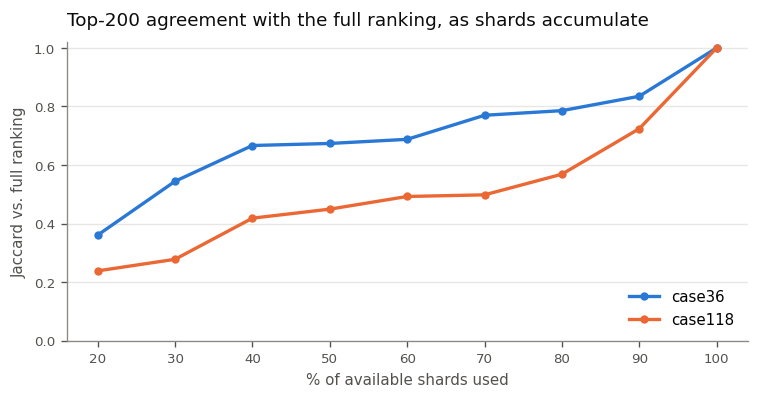

In [13]:
def jaccard(left: set, right: set) -> float:
    """Intersection over union — 1.0 when two top-k sets agree completely."""
    return len(left & right) / len(left | right) if (left or right) else float("nan")


split_rows, growth = [], {}
for grid, data in raw.items():
    good = data[data["good"]]
    even = frequency_curve(good[good["shard"] % 2 == 0])
    odd = frequency_curve(good[good["shard"] % 2 == 1])
    for k in (50, 100, 200, 400):
        split_rows.append({
            "grid": grid, "k": k,
            "even-shard rows": len(good[good["shard"] % 2 == 0]),
            "top-k Jaccard (even vs odd)": round(jaccard(set(even.index[:k]), set(odd.index[:k])), 3),
            "top-k overlap count": len(set(even.index[:k]) & set(odd.index[:k])),
        })

    shards = np.sort(good["shard"].unique())
    full = set(frequency_curve(good).index[:200])
    fractions = np.linspace(0.2, 1.0, 9)
    growth[grid] = (fractions, [
        jaccard(set(frequency_curve(good[good["shard"].isin(shards[:int(len(shards) * f)])]).index[:200]), full)
        for f in fractions
    ])

fig, ax = plt.subplots(figsize=(6.4, 3.4))
for grid, (fractions, overlaps) in growth.items():
    ax.plot(fractions * 100, overlaps, color=SERIES[grid], marker="o", markersize=4, label=grid)
style(ax, title="Top-200 agreement with the full ranking, as shards accumulate",
      xlabel="% of available shards used", ylabel="Jaccard vs. full ranking")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
fig.tight_layout()

print("Top-200 Jaccard vs. the full ranking, by % of shards used:")
print(pd.DataFrame({grid: np.round(overlaps, 2) for grid, (_, overlaps) in growth.items()},
                   index=[f"{f:.0%}" for f in fractions]).T.to_string(), "\n")

pd.DataFrame(split_rows).set_index(["grid", "k"])

**Conclusion.** case36's ranking is moderately stable but still moving (split-half Jaccard 0.53 at k = 100; top-200 reaches only 0.83 agreement at 90% of shards). case118's ranking is mostly noise (Jaccard 0.16-0.25), and its array is already complete, so beyond a few dozen actions its frequency top-`k` is not well supported by the data.

## 9. Frequency is not the only ranking available

| | |
|---|---|
| **Necessary?** | Yes, because §8 shows case118's frequency ranking is weak; this checks whether a different score would give a different set. |
| **Goal** | Compare the tool's frequency ranking to three alternatives (table below). |
| **What is measured** | Spearman rank correlation between the four scores over all actions; overlap of each alternative's top-`k` with the frequency top-`k`, and the substations it touches. |
| **How to read it** | High correlation / overlap = the choice of ranking does not matter. Low overlap for `ri_mean` is expected (it favours actions picked once, by luck) and is not an argument against frequency. |

| ranking | rationale | weakness |
|---|---|---|
| `picks` | what the tool does today | a state visited often in one chronic inflates it |
| `shard_support` | breadth — how many chronic groups found it useful | coarse, capped by shard count |
| `ri_sum` | total rho relief delivered = `picks x ri_mean` | still frequency-dominated |
| `ri_mean` | quality per use | rewards actions picked once, by luck |

In [14]:
from scipy.stats import spearmanr

RANKINGS = ["picks", "shard_support", "ri_sum", "ri_mean"]

correlation_frames = {}
for grid, table in tables.items():
    correlation = pd.DataFrame(index=RANKINGS, columns=RANKINGS, dtype=float)
    for a in RANKINGS:
        for b in RANKINGS:
            correlation.loc[a, b] = spearmanr(table[a], table[b]).statistic
    correlation_frames[grid] = correlation.round(2)

overlap_rows = []
for grid, table in tables.items():
    for k in (50, 100, 200):
        if k > len(table):
            continue
        by_picks = set(table.nlargest(k, "picks")["encoded"])
        for ranking in RANKINGS[1:]:
            alternative = set(table.nlargest(k, ranking)["encoded"])
            overlap_rows.append({
                "grid": grid, "k": k, "ranking": ranking,
                "shared with top-k by picks": len(by_picks & alternative),
                "as a share": f"{len(by_picks & alternative) / k:.0%}",
                "substations": table.nlargest(k, ranking)["sub"].nunique(),
            })

print("Spearman correlation between rankings")
for grid, correlation in correlation_frames.items():
    print(f"\n{grid}:")
    print(correlation.to_string())

pd.DataFrame(overlap_rows).set_index(["grid", "k", "ranking"])

Spearman correlation between rankings

case36:
               picks  shard_support  ri_sum  ri_mean
picks           1.00           1.00    0.72     0.07
shard_support   1.00           1.00    0.72     0.07
ri_sum          0.72           0.72    1.00     0.71
ri_mean         0.07           0.07    0.71     1.00

case118:
               picks  shard_support  ri_sum  ri_mean
picks           1.00           0.99    0.59     0.05
shard_support   0.99           1.00    0.57     0.04
ri_sum          0.59           0.57    1.00     0.82
ri_mean         0.05           0.04    0.82     1.00


shared with top-k by picks as a share  substations
grid    k   ranking                                                          
case36  50  shard_support                          50       100%           19
            ri_sum                                 42        84%           17
            ri_mean                                 0         0%            3
        100 shard_support                          99        99%           23
            ri_sum                                 81        81%           23
            ri_mean                                 0         0%            5
        200 shard_support                         197        98%           25
            ri_sum                                166        83%           25
            ri_mean                                 6         3%            7
case118 50  shard_support                          48        96%           19
            ri_sum                                 32        64%           18
            ri_mean                                 0         0%           13
        100 shard_support                          98        98%           30
            ri_sum                                 61        61%           25
            ri_mean                                 0         0%           23
        200 shard_support                         195        98%           39
            ri_sum                                127        64%           32
            ri_mean                                10         5%           30

**Conclusion.** `picks` and `shard_support` are near-identical (Spearman >= 0.99), so repeated picks inside one chronic block are not inflating the ranking. `ri_sum` shares 81-84% of the top-`k` with frequency on case36 but only 61-64% on case118, which again shows that case118's ranking is loosely determined.

## 10. A substation-stratified alternative to a flat top-k

| | |
|---|---|
| **Necessary?** | Only if §6 fails. Kept because case36 leans heavily on a few substations (§5), so the fallback should be costed in advance. |
| **Goal** | Cost out capping the number of actions per substation. |
| **What is measured** | For caps of 3/5/10/20 actions per substation: resulting `k`, substations, largest substation share, and picks covered — versus a flat top-`k` of the same size. |
| **How to read it** | The price of stratification is the gap between `picks covered` and `flat top-k covers`. A small gap with a large gain in substations makes stratification worth it. Note: `build_action_space.py aggregate` does not implement this; it would be exported from §14 directly. |

In [15]:
def stratified_selection(table: pd.DataFrame, per_substation: int) -> pd.DataFrame:
    """Take the `per_substation` most-picked actions at each substation, then re-sort by picks."""
    capped = (table.sort_values("picks", ascending=False)
                   .groupby("sub", group_keys=False)
                   .head(per_substation))
    return capped.sort_values("picks", ascending=False).reset_index(drop=True)


rows = []
for grid, table in tables.items():
    total_picks = table["picks"].sum()
    for cap in (3, 5, 10, 20):
        selection = stratified_selection(table, cap)
        flat = table.head(len(selection))
        rows.append({
            "grid": grid, "cap per substation": cap,
            "k": len(selection),
            "substations": selection["sub"].nunique(),
            "largest substation share": f"{selection['sub'].value_counts().iloc[0] / len(selection):.1%}",
            "picks covered": f"{selection['picks'].sum() / total_picks:.0%}",
            "flat top-k covers": f"{flat['picks'].sum() / total_picks:.0%}",
            "flat top-k substations": flat["sub"].nunique(),
        })

pd.DataFrame(rows).set_index(["grid", "cap per substation"])

k  substations largest substation share  \
grid    cap per substation                                              
case36  3                    90           33                     3.3%   
        5                   126           33                     4.0%   
        10                  193           33                     5.2%   
        20                  290           33                     6.9%   
case118 3                   172           72                     1.7%   
        5                   251           72                     2.0%   
        10                  394           72                     2.5%   
        20                  587           72                     3.4%   

                           picks covered flat top-k covers  \
grid    cap per substation                                   
case36  3                            26%               32%   
        5                            30%               36%   
        10                           37%               42%   
        20                           43%               48%   
case118 3                            21%               31%   
        5                            29%               39%   
        10                           39%               49%   
        20                           51%               60%   

                            flat top-k substations  
grid    cap per substation                          
case36  3                                       23  
        5                                       24  
        10                                      25  
        20                                      26  
case118 3                                       35  
        5                                       41  
        10                                      45  
        20                                      56

**Conclusion.** Capping at 10 actions per substation costs 5 percentage points of pick coverage on case36 (37% vs 42%) and 10 on case118 (39% vs 49%). In exchange, every reached substation is represented and the largest substation's share drops to 5% / 2.5%. That trade looks worthwhile for case36, given sub 16's dominance (§5).

## 11. Can two different base64 strings mean the same action?

| | |
|---|---|
| **Necessary?** | No longer as an experiment — the answer is structural (the teacher's encoder always puts the first object of a substation on bus 1, so busbar-label duplicates cannot occur) and was already 0 on the first run. Kept as a cheap guard, and because §13 needs `canonical_key`. |
| **Goal** | Detect actions that are different strings but the same physical split (busbar-label symmetry: `{A}` on bus 1 / `{B}` on bus 2 equals `{B}` on bus 1 / `{A}` on bus 2). |
| **What is measured** | Relabel busbars per fully-set substation in order of first appearance and count how many strings collapse. Partially set substations are not relabelled — their labels are relative to the untouched objects. |
| **How to read it** | `canonical groups holding more than one string` should be 0; anything else means the frequency counts are split across duplicates and understate those actions. |

In [16]:
def canonical_key(grid: str, encoded: str) -> bytes:
    """Busbar-label-invariant key for an action: relabel buses per fully-set substation."""
    pos2sub = position_to_substation(grid)
    topo_vect = decode_topo_vect(encoded).copy()
    for sub in np.unique(pos2sub[topo_vect > 0]):
        mask = pos2sub == sub
        if (topo_vect[mask] == 0).any():
            continue  # partially set: busbar labels are not free to permute
        configuration, mapping, next_label = topo_vect[mask].copy(), {}, 1
        for i, bus in enumerate(configuration):
            if bus <= 0:
                continue
            if bus not in mapping:
                mapping[bus] = next_label
                next_label += 1
            configuration[i] = mapping[bus]
        topo_vect[mask] = configuration
    return topo_vect.tobytes()


for grid, table in tables.items():
    pos2sub = position_to_substation(grid)
    vectors = {encoded: decode_topo_vect(encoded) for encoded in table["encoded"]}
    keys = {encoded: canonical_key(grid, encoded) for encoded in table["encoded"]}
    group_sizes = pd.Series(list(keys.values())).value_counts()

    print(f"{grid}:")
    print(f"  distinct bus values used across all actions: "
          f"{sorted({int(v) for vec in vectors.values() for v in vec})}")
    print(f"  substations touched per action: "
          f"{table['n_substations'].value_counts().to_dict()}")
    print(f"  actions leaving some object at the touched substation unset: {int((table['n_unset'] > 0).sum())}")
    print(f"  first object at the touched substation is on bus 1: "
          f"{sum(1 for enc, vec in vectors.items() for s in [np.unique(pos2sub[vec > 0])[0]] if vec[pos2sub == s][0] == 1)}"
          f"/{len(vectors)}")
    print(f"  unique encoded strings: {len(keys)}  ->  unique canonical keys: {group_sizes.size}")
    print(f"  canonical groups holding more than one string: {int((group_sizes > 1).sum())}\n")

case36:
  distinct bus values used across all actions: [0, 1, 2]
  substations touched per action: {1: 3989}
  actions leaving some object at the touched substation unset: 0
  first object at the touched substation is on bus 1: 3989/3989
  unique encoded strings: 3989  ->  unique canonical keys: 3989
  canonical groups holding more than one string: 0



case118:
  distinct bus values used across all actions: [0, 1, 2]
  substations touched per action: {1: 1724}
  actions leaving some object at the touched substation unset: 0
  first object at the touched substation is on bus 1: 1724/1724
  unique encoded strings: 1724  ->  unique canonical keys: 1724
  canonical groups holding more than one string: 0



**Conclusion.** 0 busbar-label duplicates on both grids, as the encoder guarantees; the guard passes.

## 12. "Reset to reference" actions

| | |
|---|---|
| **Necessary?** | Yes, for interpretation — the top-ranked action on both grids is one of these. |
| **Goal** | Separate actions that *merge* a substation back to its reference (all objects on bus 1) from actions that *split* it. |
| **What is measured** | Count, picks and best rank of reference-configuration actions (no object on bus 2). |
| **How to read it** | These are only useful from an already-split state (reached earlier in the chronic by the teacher's own actions). A large share means part of the ranking is 'undo' moves whose value depends on the teacher's trajectory, not only on the grid. |

In [17]:
for grid, table in tables.items():
    reference = table[(table["n_on_bus2"] == 0) & (table["n_unset"] == 0)]
    print(f"{grid}: {len(reference)} reference-config actions, "
          f"{reference['picks'].sum()} picks ({reference['picks'].sum() / table['picks'].sum():.1%} of all), "
          f"best rank {int(reference['rank'].min()) if len(reference) else '-'}")
    print(reference.head(5)[["rank", "sub", "picks", "shard_support", "ri_mean"]].to_string(index=False), "\n")

case36: 29 reference-config actions, 1487 picks (13.7% of all), best rank 1
 rank  sub  picks  shard_support  ri_mean
    1    1    264            189 0.122475
    2   12    137            120 0.096063
    5   11    116             99 0.096575
    6   19    107             85 0.140921
    9   35     96             86 0.128487 

case118: 54 reference-config actions, 186 picks (6.6% of all), best rank 1
 rank  sub  picks  shard_support  ri_mean
    1   79     15             14 0.118560
    3   64     14             14 0.102004
    8   49     11              9 0.076676
   10   76     10             10 0.093064
   14   22      9              9 0.109956 



**Conclusion.** 'Reset to reference' actions rank #1 on both grids and fill 5 of case36's top-10 (13.7% of its picks, vs 6.6% on case118), so a noticeable part of case36's head consists of undo moves that only help from an already-split topology.

## 13. Do the teacher's actions live inside the curated RL2Grid space?

| | |
|---|---|
| **Necessary?** | Not for choosing `k` — context for comparing against the spaces the configs use today. It is the slowest cell; set `RUN_RL2GRID_OVERLAP = False` to skip it. |
| **Goal** | Check whether the teacher finds actions the curated RL2Grid spaces already contain. |
| **What is measured** | Share of teacher actions present in `rl2grid_bus*-M_4` (after converting its `change_bus` entries to `set_bus` against the all-bus-1 reference and relabelling busbars), plus the share of the curated space the teacher ever picked. |
| **How to read it** | Read together with the structural columns: `rl2grid_bus118-M_4` is single-substation like the teacher, so overlap there is meaningful; `rl2grid_bus36-M_4` is mostly 2-3 substation combinations, so low overlap there says the spaces differ in kind, not that the teacher invented anything. |

A few entries in `rl2grid_bus118-M_4.json` name grid objects this environment does not have (e.g.
`load_23_20`) and cannot be built; they are counted and skipped. Both `M_1` files build cleanly,
so this does not affect what the configs point at today. Set `RL2GRID_FILE` to the `..._M_1.json`
files for a quick pass.

In [18]:
RL2GRID_FILE = {"case36": "rl2grid_bus36-M_4.json", "case118": "rl2grid_bus118-M_4.json"}
RUN_RL2GRID_OVERLAP = True


def change_bus_key(grid: str, action, canonicalise: bool = True) -> bytes | None:
    """Set_bus key for a change_bus action, resolved against the all-bus-1 reference topology.

    With `canonicalise`, each touched substation is relabelled so its first object sits on bus 1 —
    the same convention the teacher's encoder already follows. Comparing the counts with and
    without it measures how many entries are busbar-label duplicates of each other.
    """
    pos2sub = position_to_substation(grid)
    changed = action._change_bus_vect
    if not changed.any():
        return None  # the empty (do-nothing) entry at index 0
    topo_vect = np.zeros(len(pos2sub), dtype=np.int32)
    for sub in np.unique(pos2sub[changed]):
        mask = pos2sub == sub
        configuration = np.where(changed[mask], 2, 1).astype(np.int32)
        if canonicalise and configuration[0] == 2:
            configuration = np.where(configuration == 2, 1, 2).astype(np.int32)
        topo_vect[mask] = configuration
    return topo_vect.tobytes()


def curated_summary(grid: str, path: Path) -> dict:
    """Canonical keys for a curated action-space JSON, plus its structure and duplicate counts."""
    env = get_env(grid)
    pos2sub = position_to_substation(grid)
    with open(path, "rt", encoding="utf-8") as handle:
        dicts = json.load(handle)

    canonical, verbatim, substation_counts, unbuildable = [], set(), [], 0
    for action_dict in dicts:
        try:
            action = env.action_space(action_dict)
        except Exception:
            unbuildable += 1  # stale entry naming a load/line this environment does not have
            continue
        key = change_bus_key(grid, action)
        if key is None:
            continue
        canonical.append(key)
        verbatim.add(change_bus_key(grid, action, canonicalise=False))
        substation_counts.append(len(np.unique(pos2sub[action._change_bus_vect])))

    return {
        "entries": len(dicts),
        "unbuildable": unbuildable,
        "verbatim_keys": len(verbatim),
        "canonical_keys": len(set(canonical)),
        "substations_touched": pd.Series(substation_counts).value_counts().sort_index().to_dict(),
        "keys": set(canonical),
    }


if RUN_RL2GRID_OVERLAP:
    for grid, table in tables.items():
        reference_topology = get_env(grid).reset().topo_vect
        summary = curated_summary(grid, ACTION_SPACE_DIRS[grid] / RL2GRID_FILE[grid])
        teacher = {canonical_key(grid, encoded) for encoded in table["encoded"]}
        curated = summary["keys"]
        label_duplicates = summary["verbatim_keys"] - summary["canonical_keys"]

        print(f"{grid} vs {RL2GRID_FILE[grid]}:")
        print(f"  reference topology is all bus 1: {bool((reference_topology == 1).all())}")
        print(f"  entries: {summary['entries']}  ({summary['unbuildable']} unbuildable, skipped)")
        print(f"  substations touched per entry: {summary['substations_touched']}")
        print(f"  distinct verbatim: {summary['verbatim_keys']}  ->  after busbar relabelling: "
              f"{summary['canonical_keys']}  ({label_duplicates} label-duplicates, "
              f"{label_duplicates / max(summary['verbatim_keys'], 1):.1%})")
        print(f"  teacher actions: {len(teacher)}  (all single-substation)")
        print(f"  teacher actions present in this space: {len(teacher & curated)}"
              f" ({len(teacher & curated) / len(teacher):.1%})")
        print(f"  share of this space the teacher ever picked: "
              f"{len(teacher & curated) / len(curated):.2%}\n")

case36 vs rl2grid_bus36-M_4.json:
  reference topology is all bus 1: True
  entries: 66978  (0 unbuildable, skipped)
  substations touched per entry: {1: 654, 2: 10427, 3: 55335}
  distinct verbatim: 66416  ->  after busbar relabelling: 35369  (31047 label-duplicates, 46.7%)
  teacher actions: 3989  (all single-substation)
  teacher actions present in this space: 213 (5.3%)
  share of this space the teacher ever picked: 0.60%



case118 vs rl2grid_bus118-M_4.json:
  reference topology is all bus 1: True
  entries: 72461  (25 unbuildable, skipped)
  substations touched per entry: {1: 72249}
  distinct verbatim: 72249  ->  after busbar relabelling: 72249  (0 label-duplicates, 0.0%)
  teacher actions: 1724  (all single-substation)
  teacher actions present in this space: 1670 (96.9%)
  share of this space the teacher ever picked: 2.31%



**Conclusion.** 97% of case118's teacher actions already exist in `rl2grid_bus118-M_4`, and the teacher uses only 2.3% of that space. The 5% overlap on case36 reflects that `rl2grid_bus36-M_4` is mostly 2-3-substation combinations (and 47% busbar-label duplicates), not that the teacher found anything new.

## 14. Pick `k` and export

Fill in `CHOSEN_K` from what the cells above show, then run the printed command. `aggregate`
re-derives the same ranking from the shard CSVs and runs `verify_round_trip` before writing, so
the export is the authoritative artifact — this notebook only decides the number.

If §6 and §10 say a flat top-k is too concentrated, the alternative is to build the list here with
`stratified_selection` and call `export_action_space` directly; the commented block shows how.

In [19]:
CHOSEN_K = {"case36": None, "case118": None}  # <- fill in

SPLIT_DIRS = {"case36": "l2rpn_wcci_2020", "case118": "l2rpn_wcci_2022"}
for grid, k in CHOSEN_K.items():
    if k is None:
        print(f"{grid}: k not chosen yet")
        continue
    head = tables[grid].head(k)
    print(f"{grid}: k={k} -> {head['sub'].nunique()} substations, "
          f"{head['picks'].sum() / tables[grid]['picks'].sum():.0%} of picks covered")
    print(f"  PYTHONPATH=$(pwd)/src python experiments/build_action_space.py aggregate \\\n"
          f"      --grid {grid} \\\n"
          f"      --experience \"results/teacher/{'2026_09_17_teacher_n1_case36' if grid == 'case36' else '2026_09_18_teacher_n1_case118'}/shard_*.csv\" \\\n"
          f"      --top-k {k} \\\n"
          f"      --out data/action_spaces/{SPLIT_DIRS[grid]}/teacher_n1_k{k}.json\n")

# Stratified alternative, if a flat top-k is too concentrated:
#
# from action_space_generation.export import export_action_space, verify_round_trip
# grid, cap = "case36", 10
# selection = stratified_selection(tables[grid], cap)
# env = get_env(grid)
# actions = [env.action_space({"set_bus": {"substations_id": [(int(row["sub"]), decode_topo_vect(row["encoded"])[position_to_substation(grid) == row["sub"]].tolist())]}})
#            for _, row in selection.iterrows()]
# assert verify_round_trip(actions, env)
# export_action_space(actions, ROOT / "data" / "action_spaces" / SPLIT_DIRS[grid] / f"teacher_n1_strat{cap}.json")

case36: k not chosen yet
case118: k not chosen yet


In [20]:
for env in _ENV_CACHE.values():
    env.close()
_ENV_CACHE.clear()
print("environments closed")

environments closed
